<a href="https://colab.research.google.com/github/sofiarubini02/aids-actg-175-clinical-study/blob/main/aids_actg_175_clinical_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROGETTO: Studio Clinico AIDS ACTG 175**
Sofia Rubini 2027552

Per questo progetto ho utilizzato il dataset reale [AIDS Clinical Trials Group Study 175](https://archive.ics.uci.edu/dataset/890/aids+clinical+trials+group+study+175), pubblicato nel 1996, che raccoglie informazioni dettagliate su oltre 2.000 pazienti HIV-positivi coinvolti in uno studio clinico multicentrico negli Stati Uniti.

L'obiettivo è costruire un modello predittivo che, sulla base delle variabili del paziente, riesca a:
Prevedere se un paziente affetto da AIDS avrà un esito negativo (fallimento del trattamento antiretrovirale) o meno.


Le feature comprendono:
- Dati demografici (età, genere, razza)
- Parametri clinici (peso, Karnofsky score, CD4, sintomi)
- Tipo di trattamento e anamnesi terapeutica


Il task è una classificazione binaria, dove la variabile target cid assume valore:

- 0 → il trattamento ha avuto successo
- 1 → il trattamento ha fallito


Il progetto include:
- Analisi Esplorativa dei Dati,
- Preprocessing,
- Costruzione di modelli di classificazione: Logistic Regression, Random Forest
- Valutazione su validation e test set
- Cross-validation (5-fold) per verificare la stabilità delle metriche
- Interpretazione del modello (feature importance)
- Ablation study e analisi degli errori

Questo tipo di analisi ha un impatto reale significativo, poiché può aiutare a individuare pazienti ad alto rischio e fornire supporto alle decisioni cliniche in modo più mirato e personalizzato.


# **PARTE 1**
# Importazione Librerie e Setup Iniziale

Come primo passo, preparo l’ambiente di lavoro importando tutte le librerie necessarie per lo svolgimento del progetto.

Tra queste:

- `pandas`, `numpy`, `matplotlib`, `seaborn` → per analisi ed esplorazione dei dati
- `sklearn` → per preprocessing, training, valutazione dei modelli
- `lime` → per interpretazione locale del modello
- `tqdm` → per progress bar nei loop di validazione
- `ucimlrepo` → per il caricamento diretto del dataset da UCI Machine Learning Repository

Ho inoltre impostato alcuni parametri globali per migliorare la leggibilità degli output e lo stile dei grafici. Infine, per rendere l’output più pulito, ho disattivato l’emissione di warning non critici.


In [ ]:
# Importiamo le librerie necessarie
!pip install ucimlrepo
!pip install lime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import lime
import lime.lime_tabular


import warnings

# Impostazioni ambiente
warnings.filterwarnings('ignore')
# Stile grafico e visualizzazione
sns.set(style="whitegrid", palette="viridis")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b6458d9e055a73ecb734c89ce95d38b521ab944be419abc692117db19dba51d4
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


# **PARTE 2**
# Caricamento del Dataset e ispezione Iniziale


In questa sezione procedo con il caricamento del dataset "AIDS Clinical Trials Group Study 175" tramite la libreria `ucimlrepo` e con una prima ispezione esplorativa dei dati.

Per organizzare meglio l’analisi, separo le feature dalla variabile target. Successivamente, le ricombino temporaneamente per facilitare l’ispezione iniziale del dataset.

Visualizzo quindi le prime righe del dataset ed eseguo poi un’ispezione iniziale per controllare:
- Dimensioni del dataset
- Struttura delle colonne
- Eventuali valori nulli o righe duplicate
- Numero di valori unici per colonna
- Statistiche descrittive base


In [ ]:
aids_data = fetch_ucirepo(id=890)


X_df_original = aids_data.data.features.copy()
y_df_original = aids_data.data.targets.copy()


df_original = pd.concat([X_df_original, y_df_original], axis=1)


print("Prime 5 righe delle features:")
display(X_df_original.head())

print("\n Prime 5 righe del target:")
display(y_df_original.head())


print(f"\nDimensioni del dataset completo: {df_original.shape}")
print("\nInformazioni sulle colonne:")
df_original.info()


duplicates = df_original.duplicated().sum()
print(f"\nRighe duplicate presenti: {duplicates}")


print("\nValori unici per ogni colonna:")
print(df_original.nunique())


print("\nStatistiche descrittive delle feature numeriche:")
print(df_original.describe())

Prime 5 righe delle features:


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,0,1,0,1,0,422,477,566,324
1,1002,3,61,49.4424,0,0,0,90,0,1,...,0,1,3,0,1,0,162,218,392,564
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,1,3,0,1,1,326,274,2063,1893
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,1,3,0,1,0,287,394,1590,966
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,1,3,0,0,0,504,353,870,782



 Prime 5 righe del target:


,cid
0,0
1,1
2,0
3,0
4,0



Dimensioni del dataset completo: (2139, 24)

Informazioni sulle colonne:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     2139 non-null   int64  
 1   trt      2139 non-null   int64  
 2   age      2139 non-null   int64  
 3   wtkg     2139 non-null   float64
 4   hemo     2139 non-null   int64  
 5   homo     2139 non-null   int64  
 6   drugs    2139 non-null   int64  
 7   karnof   2139 non-null   int64  
 8   oprior   2139 non-null   int64  
 9   z30      2139 non-null   int64  
 10  zprior   2139 non-null   int64  
 11  preanti  2139 non-null   int64  
 12  race     2139 non-null   int64  
 13  gender   2139 non-null   int64  
 14  str2     2139 non-null   int64  
 15  strat    2139 non-null   int64  
 16  symptom  2139 non-null   int64  
 17  treat    2139 non-null   int64  
 18  offtrt   2139 non-null   int64  
 19  cd40     2139 no

# **PARTE 3**
# EDA – Analisi Esplorativa dei Dati (dataset grezzo)


In questa sezione svolgo l’analisi esplorativa sul dataset `df_original`.

L'obiettivo è iniziare a capire:
- Come sono distribuite le variabili numeriche e categoriche
- Come varia il target `cid` in base alle altre feature
- Quali sono le variabili potenzialmente rilevanti per la classificazione

Le analisi svolte:

- Distribuzione del target `cid` (fallimento/successo)
- Istogrammi per le feature numeriche
- Boxplot per alcune variabili continue rispetto alla classe
- Countplot per variabili categoriche
- Heatmap di correlazione tra le feature numeriche
- Analisi di variabili sensibili come `gender`, `race`, `homo` e `symptom`
- Analisi per **fasce d'età** tramite discretizzazione dell’attributo `age`



Distribuzione del target (cid):
cid
0    0.756
1    0.244
Name: proportion, dtype: float64


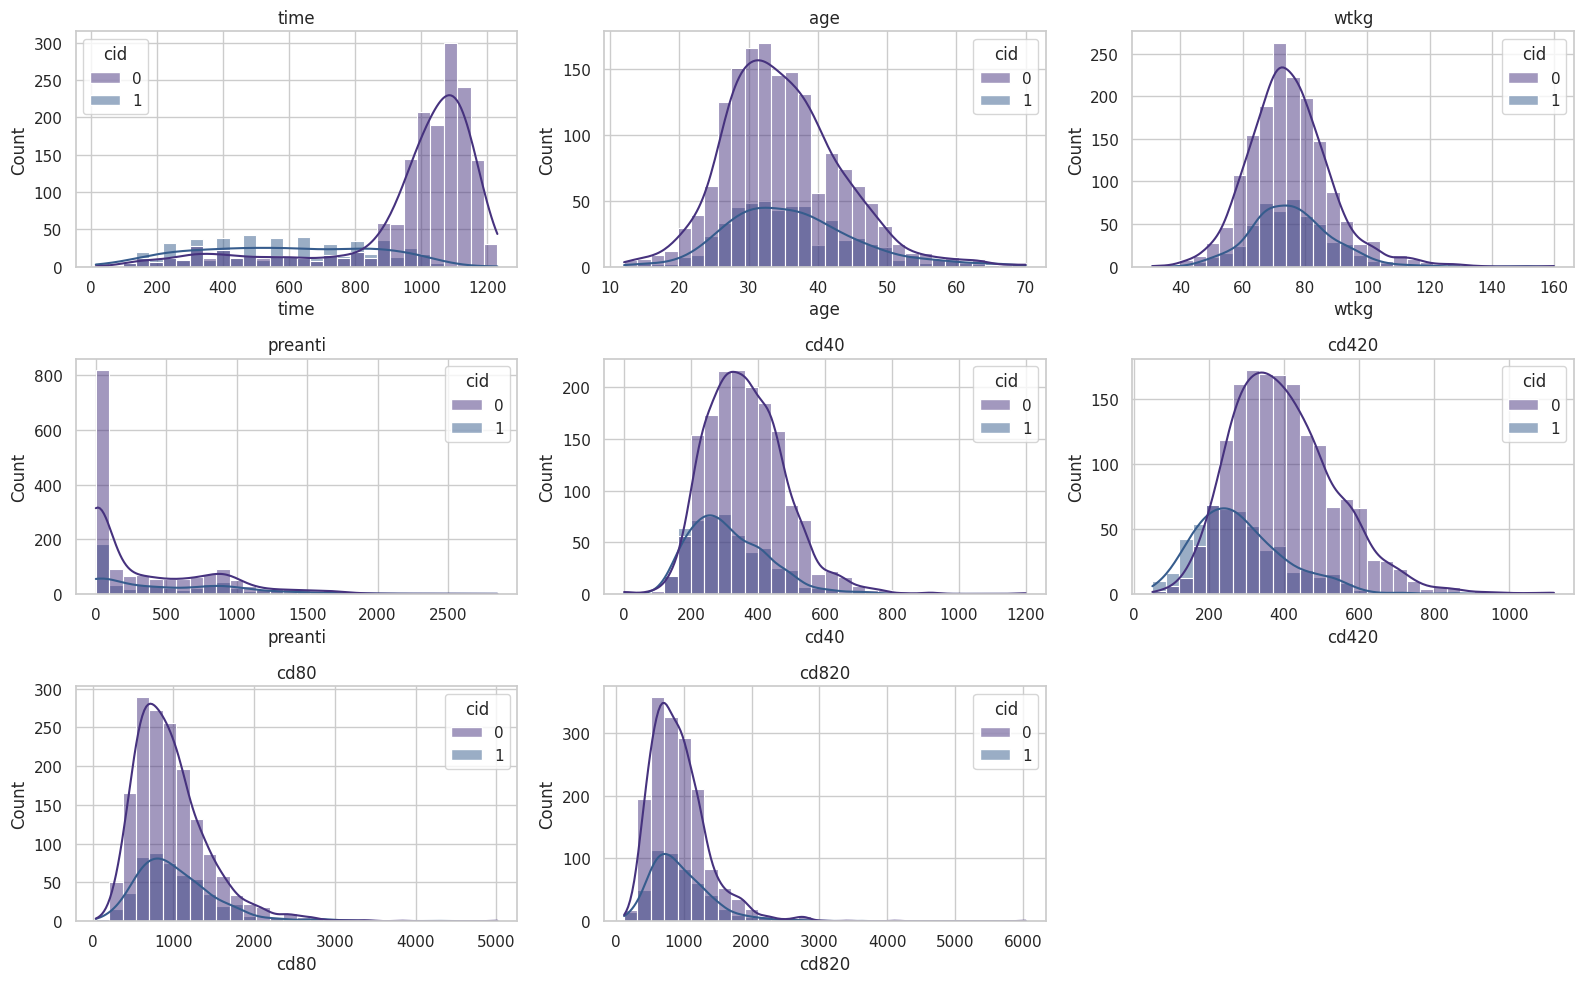

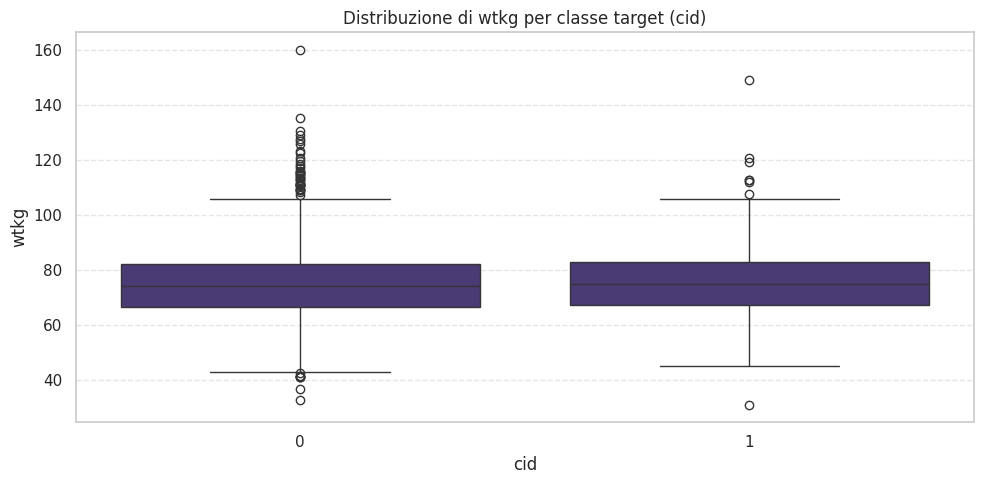

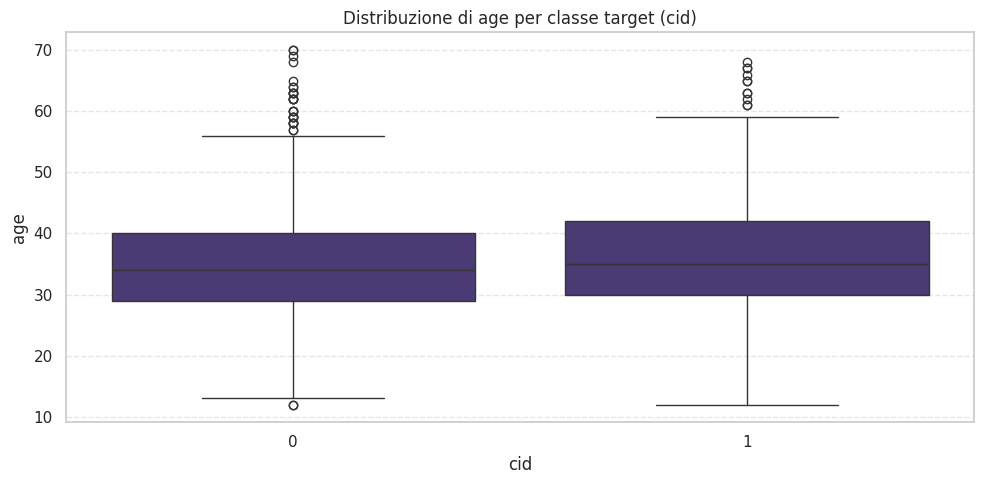

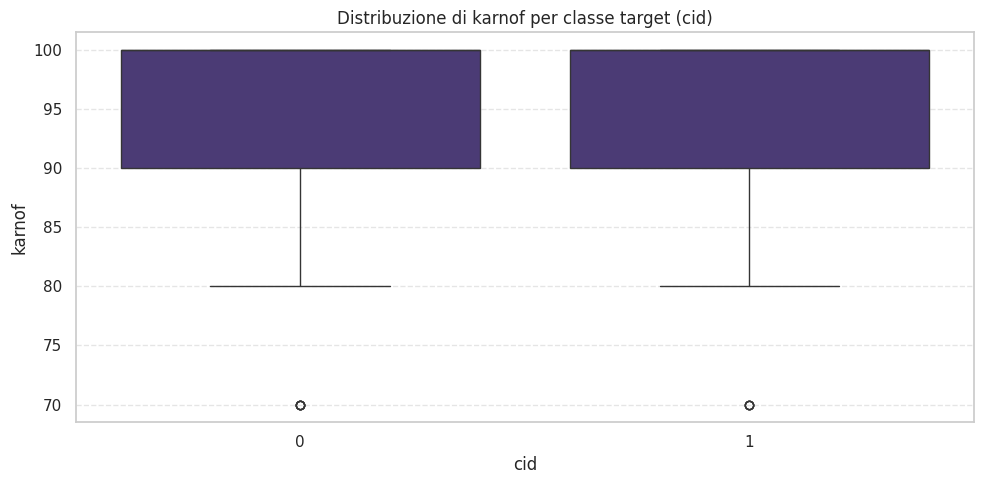

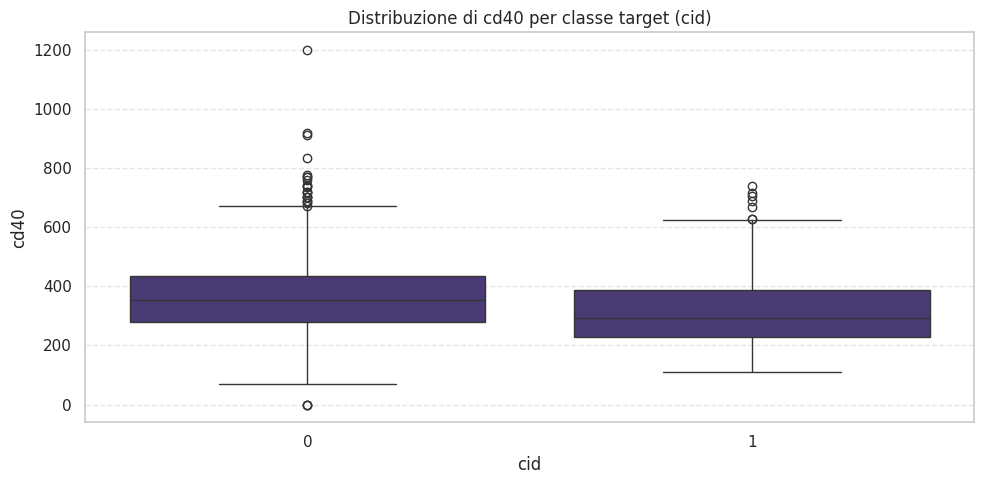

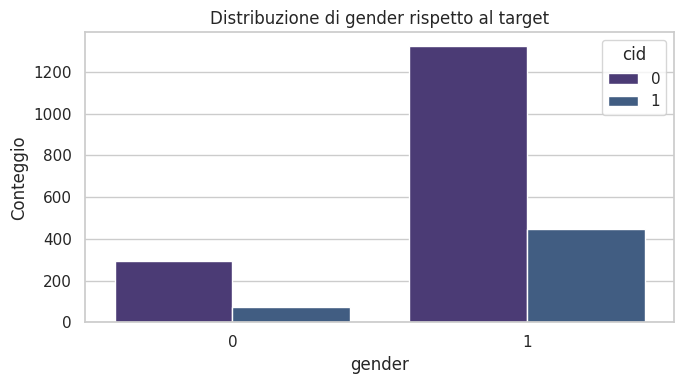

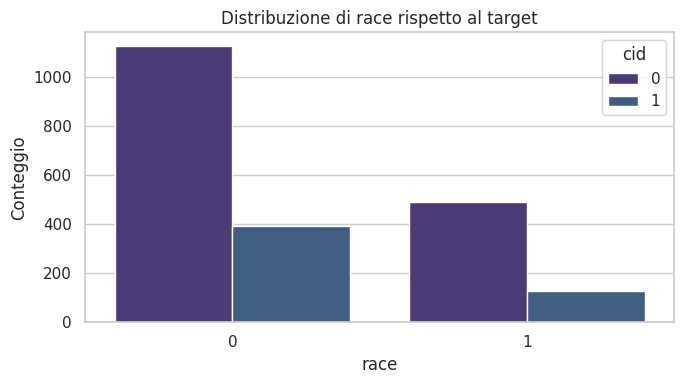

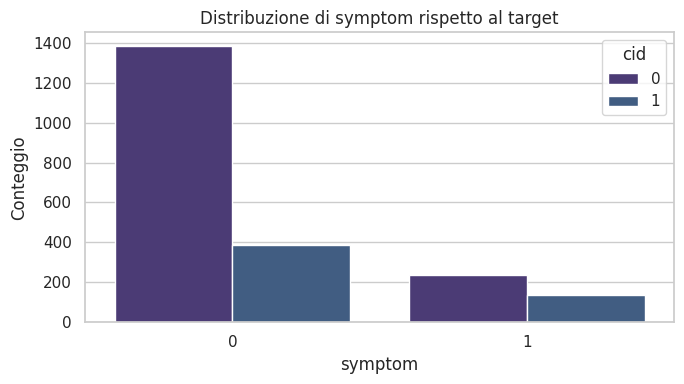

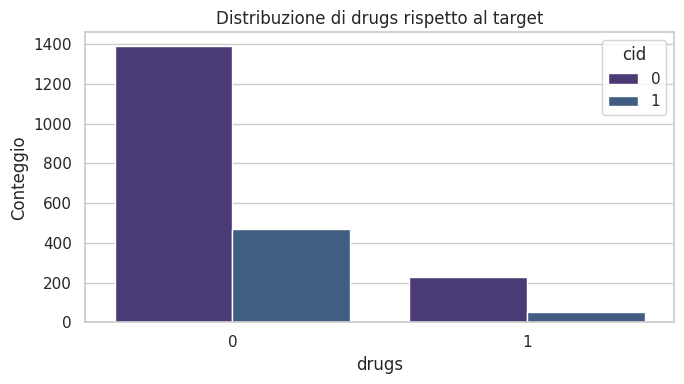

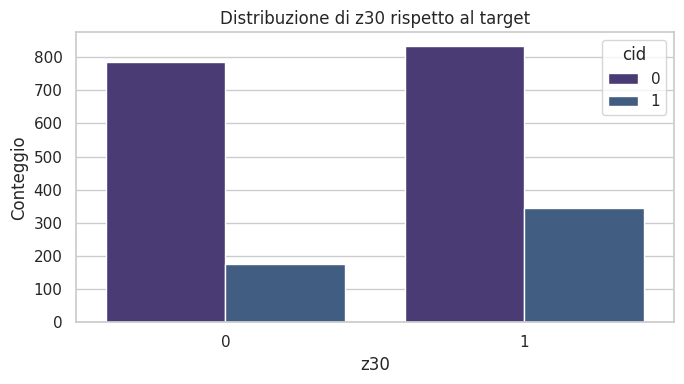

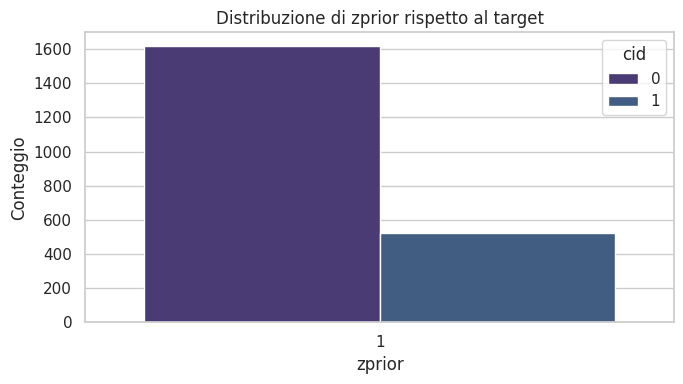

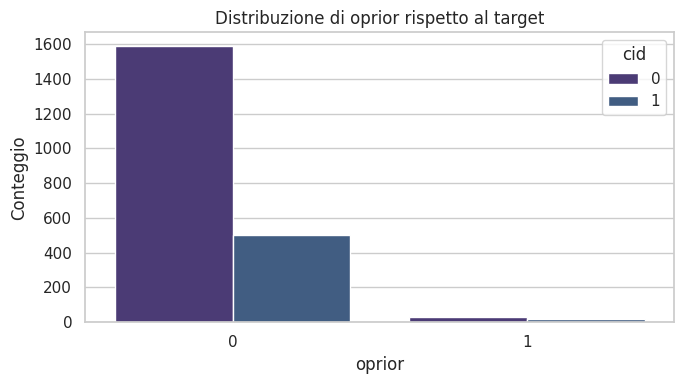

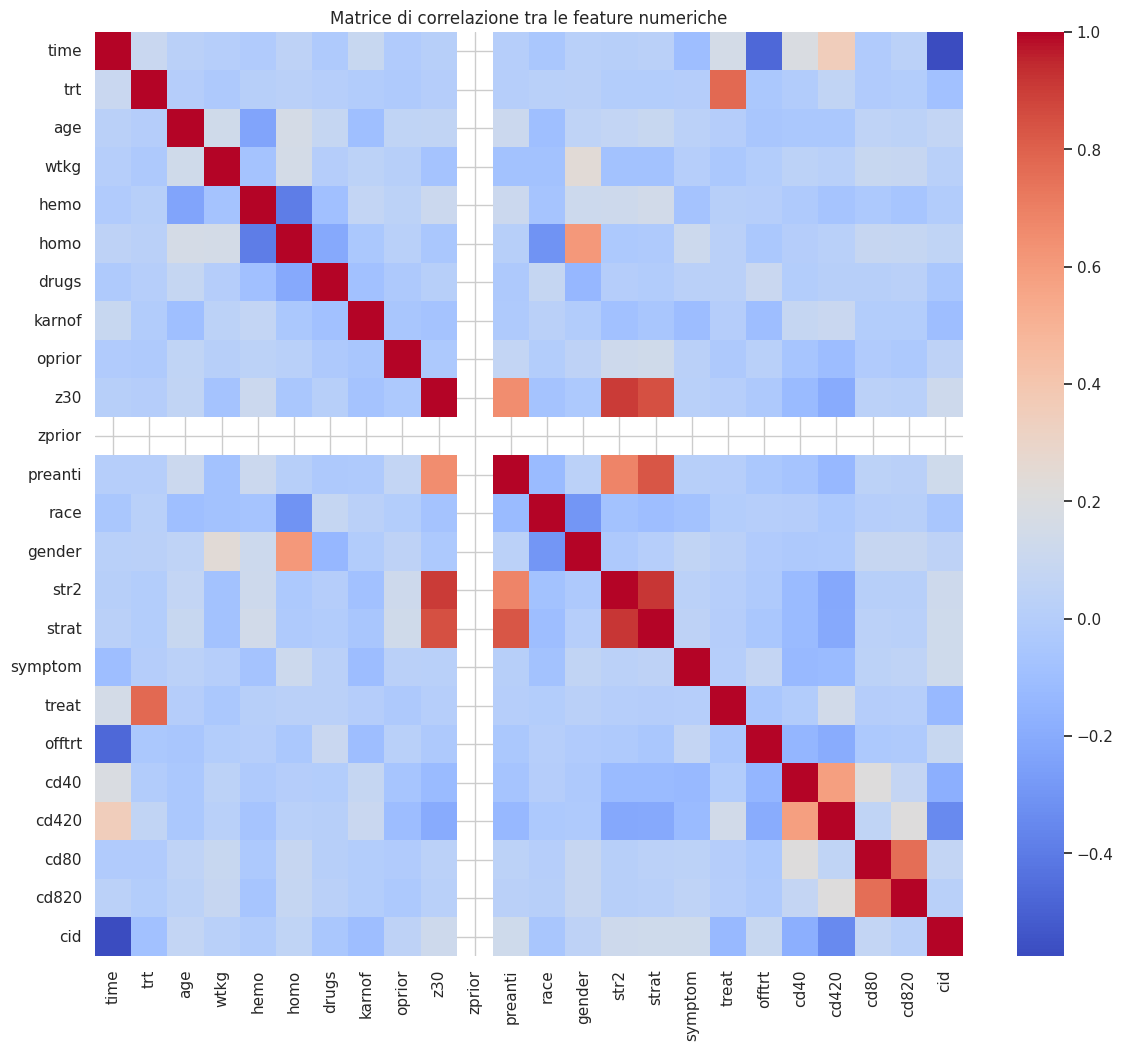

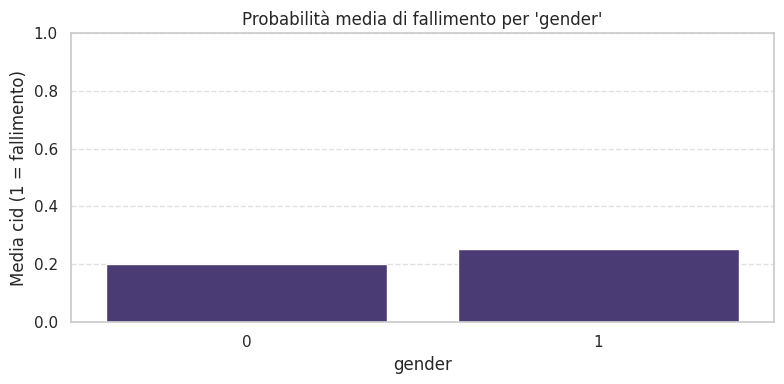


Media e conteggio cid per 'gender':
            mean  count
gender                 
0       0.201087    368
1       0.252400   1771
--------------------------------------------------


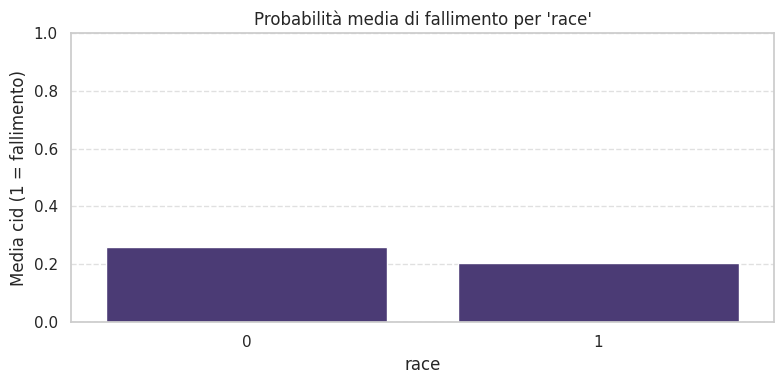


Media e conteggio cid per 'race':
          mean  count
race                 
0     0.258870   1522
1     0.205835    617
--------------------------------------------------


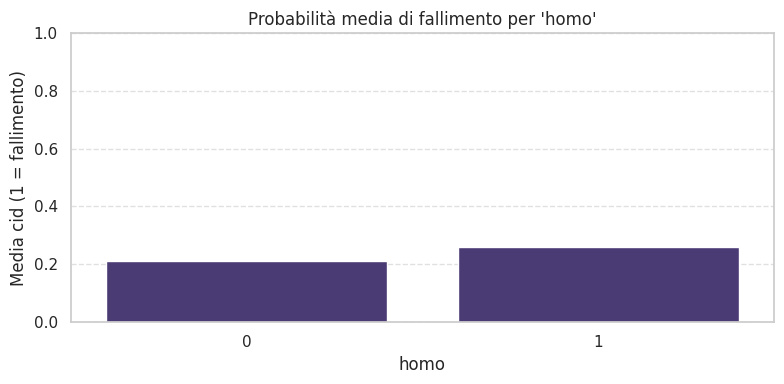


Media e conteggio cid per 'homo':
          mean  count
homo                 
0     0.211034    725
1     0.260255   1414
--------------------------------------------------


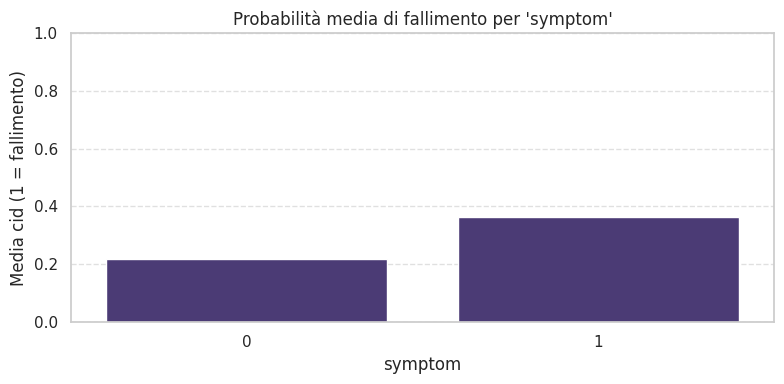


Media e conteggio cid per 'symptom':
             mean  count
symptom                 
0        0.218202   1769
1        0.364865    370
--------------------------------------------------


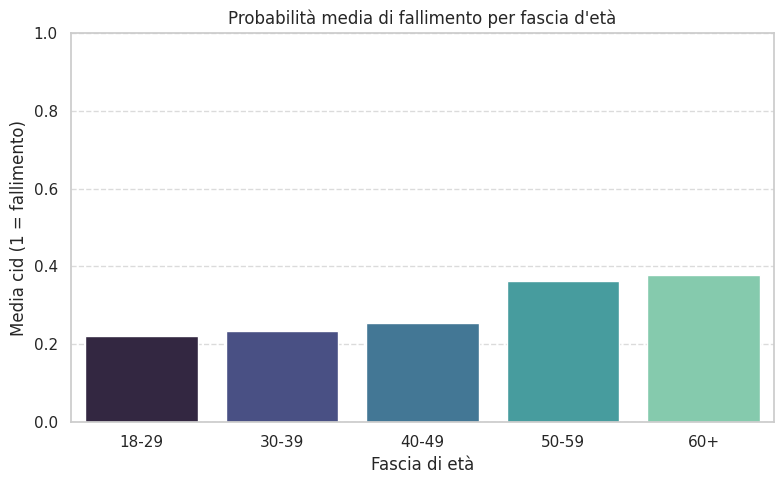


Media e conteggio cid per fascia d'età:
               mean  count
age_group                 
18-29      0.222015    536
30-39      0.234642    993
40-49      0.255965    461
50-59      0.361702     94
60+        0.379310     29
--------------------------------------------------


In [ ]:
print("\nDistribuzione del target (cid):")
print(df_original['cid'].value_counts(normalize=True).round(3))


# Istogrammi per le prime 9 feature numeriche
num_cols = [col for col in df_original.columns
             if df_original[col].nunique() > 10 and np.issubdtype(df_original[col].dtype, np.number)]

plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols[:9]):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=df_original, x=col, kde=True, hue='cid', bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


# Boxplot per 4 feature numeriche
box_cols = ['wtkg', 'age', 'karnof', 'cd40']
for col in box_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_original, x='cid', y=col)
    plt.title(f"Distribuzione di {col} per classe target (cid)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Countplot per variabili categoriche rispetto al target
cat_vars = ['gender', 'race', 'symptom', 'drugs', 'z30', 'zprior', 'oprior']
for col in cat_vars:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df_original, x=col, hue='cid', order=sorted(df_original[col].unique()))
    plt.title(f"Distribuzione di {col} rispetto al target")
    plt.xlabel(col)
    plt.ylabel("Conteggio")
    plt.tight_layout()
    plt.show()


# Heatmap delle correlazioni
plt.figure(figsize=(14, 12))
corr = df_original.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matrice di correlazione tra le feature numeriche")
plt.show()


df_sensitive = df_original.copy()
# Definiasco le variabili sensibili rilevanti nel mio dataset
sensitive_attributes = ['gender', 'race', 'homo', 'symptom']

for attr in sensitive_attributes:
    if attr in df_sensitive.columns:
        plt.figure(figsize=(8, 4))
        sns.barplot(x=attr, y='cid', data=df_sensitive, ci=None)
        plt.title(f"Probabilità media di fallimento per '{attr}'")
        plt.ylabel("Media cid (1 = fallimento)")
        plt.xlabel(attr)
        plt.xticks([0, 1], labels=['0', '1'])
        plt.grid(axis='y', linestyle='--', alpha=0.6)

        plt.ylim(0, 1)

        plt.tight_layout()
        plt.show()

        print(f"\nMedia e conteggio cid per '{attr}':")
        print(df_sensitive.groupby(attr)['cid'].agg(['mean', 'count']))
        print("-" * 50)


# Creazione fasce di età
age_bins = [18, 30, 40, 50, 60, 80]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df_sensitive['age_group'] = pd.cut(df_sensitive['age'], bins=age_bins, labels=age_labels, right=False)

# Barplot per età
plt.figure(figsize=(8, 5))
sns.barplot(x='age_group', y='cid', data=df_sensitive, palette='mako', ci=None)
plt.title("Probabilità media di fallimento per fascia d'età")
plt.ylabel("Media cid (1 = fallimento)")
plt.xlabel("Fascia di età")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# Tabella riepilogativa per età
print("\nMedia e conteggio cid per fascia d'età:")
print(df_sensitive.groupby('age_group')['cid'].agg(['mean', 'count']))
print("-" * 50)

# **PARTE 4**

# Preprocessing e suddivisione del dataset

In questa fase eseguo il preprocessing del dataset: rimuovo la feature costante zprior, separo le feature dal target e distinguo le variabili numeriche da quelle binarie già codificate.
Applico quindi lo StandardScaler solo alle variabili numeriche, lasciando passare le binarie senza trasformazione.
Infine, eseguo lo split stratificato in train, validation e test e trasformo tutto in DataFrame per facilitare l’analisi successiva.

In [ ]:
df_clean = df_original.copy()


df_clean = df_clean.drop(columns=['zprior'], errors='ignore')

# Separazione feature / target
X = df_clean.drop(columns='cid')
y = df_clean['cid']

# Definisco le feature binarie (già codificate)
binary_features = ['gender', 'race', 'symptom', 'drugs', 'z30', 'oprior', 'homo']
# Seleziono tutte le altre feature numeriche da scalare
numeric_features = [col for col in X.columns if col not in binary_features]

# Preprocessing
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        # le binary_features non vengono trasformate, vengono passate così come sono
        ('bin', 'passthrough', binary_features)
    ]
)

# Split stratificato: train (64%), validation (16%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

# Applico il preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Ottengo i nomi delle nuove feature
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = numeric_features + binary_features

# Converto in DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_df = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)


print("\nDimensioni dei dataset dopo preprocessing:")
print(f"Train:      {X_train_df.shape}")
print(f"Validation: {X_val_df.shape}")
print(f"Test:       {X_test_df.shape}")


Dimensioni dei dataset dopo preprocessing:
Train:      (1368, 22)
Validation: (343, 22)
Test:       (428, 22)


# Logistic Regression

In questa fase addestro un primo modello di classificazione utilizzando la Regressione Logistica.

Alleno il modello sul training set preprocessato e poi valuto le sue performance sul validation set.
Stampo le metriche principali (accuracy, precision, recall, f1-score) e visualizzo la matrice di confusione per per capire la distribuzione degli errori tra classi positive e negative.

 Classification Report (Validation Set):
              precision    recall  f1-score   support

           0      0.898     0.954     0.925       259
           1      0.824     0.667     0.737        84

    accuracy                          0.883       343
   macro avg      0.861     0.810     0.831       343
weighted avg      0.880     0.883     0.879       343


 Metriche principali:
 Accuracy:  0.883
 Precision: 0.824
 Recall:    0.667
 F1-score:  0.737


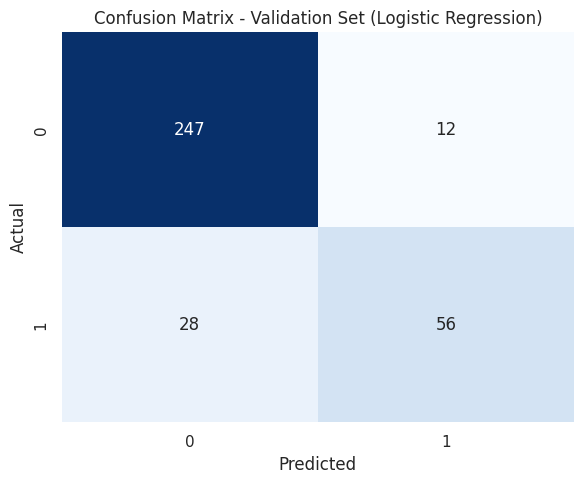

In [ ]:
# Addestro sul training set preprocessato
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_df, y_train)

# Predizione sul validation set
y_val_pred = log_reg.predict(X_val_df)

# Valutazione
print(" Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, digits=3))

print("\n Metriche principali:")
print(" Accuracy: ", round(accuracy_score(y_val, y_val_pred), 3))
print(" Precision:", round(precision_score(y_val, y_val_pred), 3))
print(" Recall:   ", round(recall_score(y_val, y_val_pred), 3))
print(" F1-score: ", round(f1_score(y_val, y_val_pred), 3))

# Matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Validation Set (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Random Forest

Dopo il modello baseline, alleno una **Random Forest**, un ensemble di alberi decisionali in grado di catturare relazioni anche non lineari tra le variabili.

Utilizzo 100 alberi (`n_estimators=100`) e imposto `class_weight='balanced'` per gestire l'eventuale sbilanciamento tra le classi. Dopo l’addestramento sul training set, valuto il modello sul validation set analizzando le metriche principali e la matrice di confusione per capire meglio il tipo di errori commessi.



Classification Report (Random Forest)
              precision    recall  f1-score   support

           0      0.904     0.942     0.922       259
           1      0.795     0.690     0.739        84

    accuracy                          0.880       343
   macro avg      0.849     0.816     0.831       343
weighted avg      0.877     0.880     0.878       343

Metriche principali:
 Accuracy:   0.88
 Precision: 0.795
 Recall:    0.69
 F1-score:  0.739


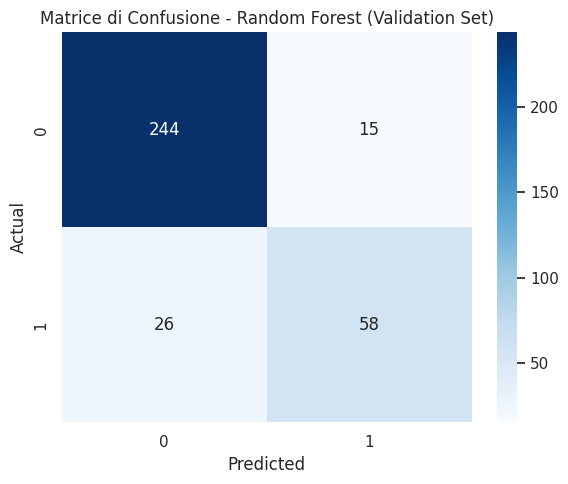

In [ ]:
# Inizializzazione del modello
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'  # per gestire eventuale sbilanciamento
)

# Addestramento
rf_model.fit(X_train_df, y_train)

# Predizione sul validation set
y_val_pred_rf = rf_model.predict(X_val_df)


# Valutazione sul Validation Set


print("Classification Report (Random Forest)")
print(classification_report(y_val, y_val_pred_rf, digits=3))

print("Metriche principali:")
print(" Accuracy:  ", round(accuracy_score(y_val, y_val_pred_rf), 3))
print(" Precision:", round(precision_score(y_val, y_val_pred_rf), 3))
print(" Recall:   ", round(recall_score(y_val, y_val_pred_rf), 3))
print(" F1-score: ", round(f1_score(y_val, y_val_pred_rf), 3))


plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matrice di Confusione - Random Forest (Validation Set)")
plt.tight_layout()
plt.show()

# Random Forest - Ottimizzazione tramite RandomizedSearchCV


Per migliorare le prestazioni della Random Forest, applico un'ottimizzazione degli iperparametri tramite `RandomizedSearchCV`.  
Esploro diverse combinazioni per `n_estimators`, `max_depth`, `min_samples_split` e `min_samples_leaf`, utilizzando una validazione incrociata a 5 fold.  
L'obiettivo è trovare un set di iperparametri più efficace rispetto ai valori di default, mantenendo tempi di calcolo contenuti.

Come metrica di valutazione uso l'F1-score, più indicata in caso di classi sbilanciate. Al termine della ricerca, valuto le performance del miglior modello sul validation set.



Migliori iperparametri trovati:
{'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 183}

Classification Report (Random Forest Ottimizzata):
              precision    recall  f1-score   support

           0      0.941     0.927     0.934       259
           1      0.784     0.821     0.802        84

    accuracy                          0.901       343
   macro avg      0.863     0.874     0.868       343
weighted avg      0.903     0.901     0.902       343



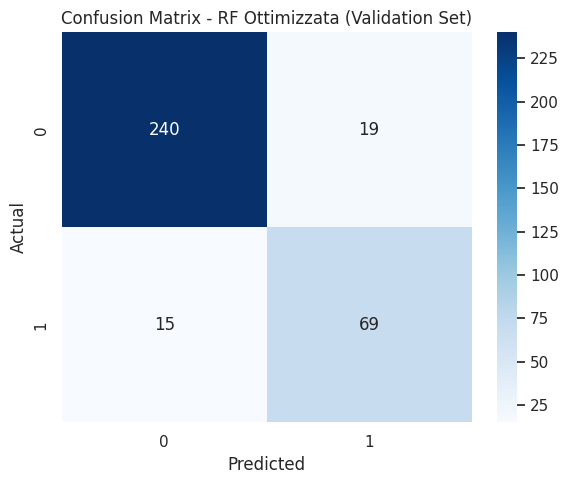

In [ ]:
# Spazio di ricerca per gli iperparametri
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# RandomizedSearchCV con 5-fold CV
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Fit sul training set
random_search.fit(X_train_df, y_train)

# Miglior modello trovato
best_rf = random_search.best_estimator_
print("Migliori iperparametri trovati:")
print(random_search.best_params_)

# Valutazione sul validation set
y_val_pred_best = best_rf.predict(X_val_df)

print("\nClassification Report (Random Forest Ottimizzata):")
print(classification_report(y_val, y_val_pred_best, digits=3))

# Matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RF Ottimizzata (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Cross-Validation

Applico una validazione incrociata (5-fold Stratified Cross-Validation) al modello di Random Forest per ottenere una valutazione più robusta delle sue prestazioni.  
Divido il training set in 5 sottoinsiemi stratificati, in modo da mantenere la proporzione delle classi in ciascun fold.  
Per ogni iterazione, alleno il modello su 4 fold e valuto sul fold rimanente, calcolando precision, recall e F1-score.  
Alla fine, calcolo la media delle metriche ottenute per avere un'indicazione generale delle performance del modello su dati non visti.


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
precisions, recalls, f1_scores = [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_df, y_train)):
    X_fold_train, X_fold_val = X_train_df.iloc[train_idx], X_train_df.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf_cv = RandomForestClassifier(random_state=42)
    rf_cv.fit(X_fold_train, y_fold_train)

    y_pred_cv = rf_cv.predict(X_fold_val)

    precisions.append(precision_score(y_fold_val, y_pred_cv))
    recalls.append(recall_score(y_fold_val, y_pred_cv))
    f1_scores.append(f1_score(y_fold_val, y_pred_cv))

    print(f"Fold {fold+1}: Precision={precisions[-1]:.3f}, Recall={recalls[-1]:.3f}, F1={f1_scores[-1]:.3f}")

print("\nMedia metriche cross-validation:")
print(f"Precisione media: {np.mean(precisions):.3f}")
print(f"Recall medio:     {np.mean(recalls):.3f}")
print(f"F1-score medio:   {np.mean(f1_scores):.3f}")

Fold 1: Precision=0.770, Recall=0.701, F1=0.734
Fold 2: Precision=0.772, Recall=0.657, F1=0.710
Fold 3: Precision=0.815, Recall=0.657, F1=0.727
Fold 4: Precision=0.793, Recall=0.697, F1=0.742
Fold 5: Precision=0.811, Recall=0.652, F1=0.723

Media metriche cross-validation:
Precisione media: 0.792
Recall medio:     0.673
F1-score medio:   0.727


Applico una validazione incrociata (5-fold stratificata) anche al modello di **Logistic Regression** per valutare la sua stabilità e le performance medie su diversi split del training set.


In [ ]:
# Inizializza KFold stratificato
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Liste per salvare le metriche
precisions_log, recalls_log, f1_scores_log = [], [], []

# Cross-validation manuale
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_df, y_train)):
    X_fold_train, X_fold_val = X_train_df.iloc[train_idx], X_train_df.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Modello Logistic Regression
    log_cv = LogisticRegression(random_state=42, max_iter=1000)
    log_cv.fit(X_fold_train, y_fold_train)

    y_pred_cv = log_cv.predict(X_fold_val)

    # Metriche
    precisions_log.append(precision_score(y_fold_val, y_pred_cv))
    recalls_log.append(recall_score(y_fold_val, y_pred_cv))
    f1_scores_log.append(f1_score(y_fold_val, y_pred_cv))

    print(f"Fold {fold+1}: Precision={precisions_log[-1]:.3f}, Recall={recalls_log[-1]:.3f}, F1={f1_scores_log[-1]:.3f}")

# Medie finali
print("\n==> Metriche medie Logistic Regression:")
print(f"Precision media: {np.mean(precisions_log):.3f}")
print(f"Recall media:    {np.mean(recalls_log):.3f}")
print(f"F1-score media:  {np.mean(f1_scores_log):.3f}")

Fold 1: Precision=0.727, Recall=0.597, F1=0.656
Fold 2: Precision=0.729, Recall=0.642, F1=0.683
Fold 3: Precision=0.830, Recall=0.582, F1=0.684
Fold 4: Precision=0.765, Recall=0.591, F1=0.667
Fold 5: Precision=0.816, Recall=0.606, F1=0.696

==> Metriche medie Logistic Regression:
Precision media: 0.773
Recall media:    0.604
F1-score media:  0.677


In [ ]:
# Riepilogo cross-validation: Random Forest vs Logistic Regression
cv_summary = pd.DataFrame({
    'Modello': ['Random Forest', 'Logistic Regression'],
    'Precision_mean': [np.mean(precisions), np.mean(precisions_log)],
    'Precision_std' : [np.std(precisions), np.std(precisions_log)],
    'Recall_mean'   : [np.mean(recalls), np.mean(recalls_log)],
    'Recall_std'    : [np.std(recalls), np.std(recalls_log)],
    'F1_mean'       : [np.mean(f1_scores), np.mean(f1_scores_log)],
    'F1_std'        : [np.std(f1_scores), np.std(f1_scores_log)],
})

print("\nRiepilogo Cross-Validation (5-fold)")
display(cv_summary.round(3))


Riepilogo Cross-Validation (5-fold)


,Modello,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,Random Forest,0.792,0.019,0.673,0.022,0.727,0.011
1,Logistic Regression,0.773,0.043,0.604,0.021,0.677,0.014



La **Random Forest** mostra prestazioni superiori in tutte le metriche rispetto alla **Logistic Regression**, con un F1-score medio di `0.727` contro `0.677`.  
Inoltre, ha una **deviazione standard più bassa**, segno che il modello è anche più stabile nei diversi fold.

Sulla base di questi risultati, la Random Forest risulta essere il modello migliore in termini di performance e affidabilità.

Con questo boxplot confronto la distribuzione del **F1-score** ottenuto nei 5 fold di cross-validation per i due modelli.

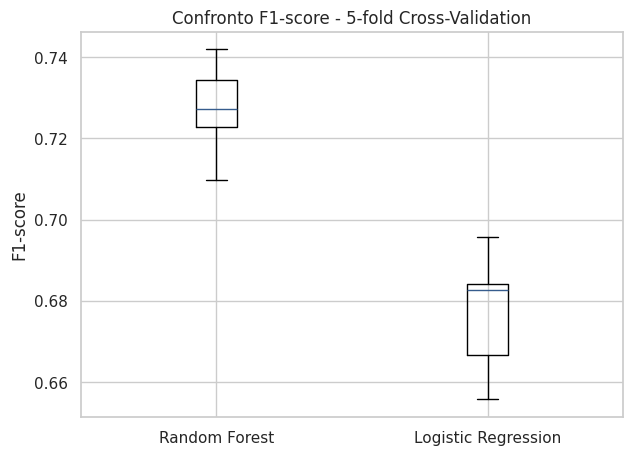

In [ ]:
# Boxplot comparativo F1-score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.boxplot([f1_scores, f1_scores_log], labels=['Random Forest', 'Logistic Regression'])
plt.title("Confronto F1-score - 5-fold Cross-Validation")
plt.ylabel("F1-score")
plt.grid(True)
plt.show()

# Confronto dei Modelli – Validation Set

In questa sezione confronto le performance dei due modelli principali: **Logistic Regression** e **Random Forest**.

Per ciascun modello calcolo le metriche principali (Accuracy, Precision, Recall e F1-score) sul validation set.

Presento i risultati sia in formato tabellare che tramite grafico a barre, per facilitare il confronto tra i due approcci.

Questo mi permette di scegliere con più consapevolezza quale modello portare in fase di test finale.


Confronto Modelli (Validation Set)


,Modello,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.883,0.824,0.667,0.737
1,Random Forest,0.880,0.795,0.690,0.739


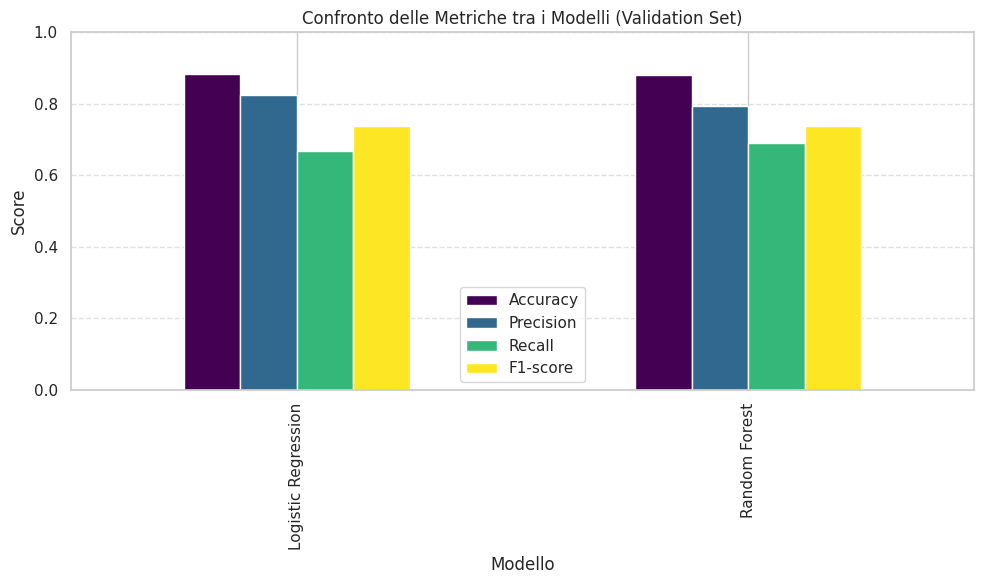

In [ ]:
# Predizioni
y_val_pred = log_reg.predict(X_val_df)
y_val_pred_rf = rf_model.predict(X_val_df)

# Metriche a confronto
models = ['Logistic Regression', 'Random Forest']
accuracies = [
    round(accuracy_score(y_val, y_val_pred), 3),
    round(accuracy_score(y_val, y_val_pred_rf), 3)
]
precisions = [
    round(precision_score(y_val, y_val_pred), 3),
    round(precision_score(y_val, y_val_pred_rf), 3)
]
recalls = [
    round(recall_score(y_val, y_val_pred), 3),
    round(recall_score(y_val, y_val_pred_rf), 3)
]
f1_scores = [
    round(f1_score(y_val, y_val_pred), 3),
    round(f1_score(y_val, y_val_pred_rf), 3)
]

# Creazione tabella comparativa
comparison_df = pd.DataFrame({
    'Modello': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-score': f1_scores
})

print("Confronto Modelli (Validation Set)")
display(comparison_df)

# Visualizzazione grafica
comparison_df.set_index('Modello').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Confronto delle Metriche tra i Modelli (Validation Set)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretazione del Confronto tra Modelli

Entrambi i modelli mostrano buone performance sul validation set, con una accuracy simile (~88%).  
La **Logistic Regression** è leggermente più precisa, mentre la **Random Forest** ha un recall più alto, ovvero riesce a individuare meglio i pazienti a rischio di fallimento del trattamento.

Nel complesso, i due modelli sono molto vicini anche in termini di F1-score.  
La scelta finale può dipendere dal contesto clinico: se è più importante intercettare **tutti i possibili pazienti a rischio** (come nel nostro caso), Random Forest potrebbe essere preferibile per il suo maggiore recall.


# Analisi delle Feature Importanti – Random Forest

In questa sezione analizzo le feature più rilevanti per il modello Random Forest, utilizzando il metodo `.feature_importances_`.  
Questa tecnica assegna un'importanza a ciascuna variabile in base a quanto aiuta il modello a prendere decisioni più accurate all’interno degli alberi decisionali.

Dapprima costruiamo una tabella ordinata con tutte le feature e la loro importanza relativa.  
Successivamente, visualizziamo graficamente le 10 feature più significative.  
Questa analisi è fondamentale per comprendere **quali variabili cliniche influenzano maggiormente la probabilità di fallimento del trattamento** nei pazienti analizzati.


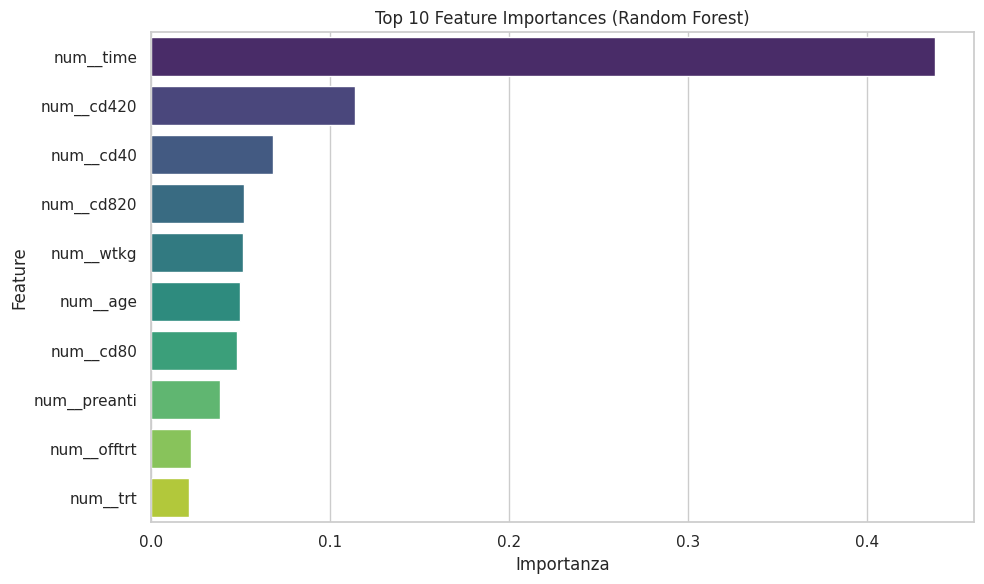

,Feature,Importance
0,num__time,0.437702
12,num__cd420,0.114327
11,num__cd40,0.068410
14,num__cd820,0.052006
3,num__wtkg,0.051592
2,num__age,0.049826
13,num__cd80,0.048042
6,num__preanti,0.038886
10,num__offtrt,0.022533
1,num__trt,0.021399


In [ ]:
# Otteniamo l'importanza delle feature dal modello
importances = rf_model.feature_importances_
features = X_train_df.columns

# Creiamo un DataFrame ordinato
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot delle Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Tabella completa delle feature ordinate
display(feat_df)

# Ablation Study: rimozione della feature più importante

Per testare la robustezza del modello, ho condotto un **ablation study** rimuovendo dal training set la feature più importante individuata dall'analisi precedente (`{top_feature}`).

Ho quindi riaddestrato un nuovo modello Random Forest senza questa variabile e confrontato le sue performance su validation set.

L'obiettivo è osservare quanto le metriche peggiorano in assenza di una feature critica: se il calo è minimo, il modello è robusto; se il calo è marcato, significa che il modello è troppo dipendente da quella feature.



In [ ]:
# Prendo la feature più importante
top_feature = feat_df.iloc[0]['Feature']
print(f"Feature più importante da rimuovere: {top_feature}")

# Rimuovo la feature più importante dai dati preprocessati
X_train_ablation = X_train_df.drop(columns=[top_feature])
X_val_ablation = X_val_df.drop(columns=[top_feature])

# Alleno un nuovo modello su questi dati
rf_ablation = RandomForestClassifier(random_state=42)
rf_ablation.fit(X_train_ablation, y_train)

# Predizione
y_val_pred_ablation = rf_ablation.predict(X_val_ablation)

# Valutazione
print("\nAblation Study - Senza Feature Principale")
print(classification_report(y_val, y_val_pred_ablation, digits=3))

Feature più importante da rimuovere: num__time

Ablation Study - Senza Feature Principale
              precision    recall  f1-score   support

           0      0.792     0.942     0.861       259
           1      0.571     0.238     0.336        84

    accuracy                          0.770       343
   macro avg      0.682     0.590     0.598       343
weighted avg      0.738     0.770     0.732       343



# Confronto le Metriche prima e dopo Ablation

Nel grafico seguente metto a confronto le metriche di classificazione del modello Random Forest completo con quelle ottenute dopo la rimozione della feature più importante (`num__time`).

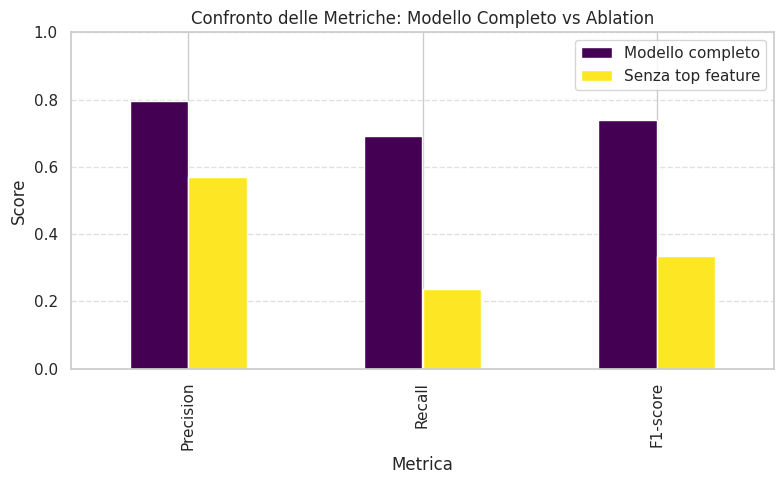

,Metrica,Modello completo,Senza top feature
0,Precision,0.795,0.571
1,Recall,0.690,0.238
2,F1-score,0.739,0.336


In [ ]:
# Calcolo F1, Precision, Recall per entrambe le versioni
metrics = ['Precision', 'Recall', 'F1-score']
pre_values = [
    precision_score(y_val, y_val_pred_rf),
    recall_score(y_val, y_val_pred_rf),
    f1_score(y_val, y_val_pred_rf)
]
post_values = [
    precision_score(y_val, y_val_pred_ablation),
    recall_score(y_val, y_val_pred_ablation),
    f1_score(y_val, y_val_pred_ablation)
]

# Tabella per confronto
ablation_df = pd.DataFrame({
    'Metrica': metrics,
    'Modello completo': pre_values,
    'Senza top feature': post_values
})

# Plot
ablation_df.set_index('Metrica').plot(kind='bar', figsize=(8, 5), colormap='viridis')
plt.title("Confronto delle Metriche: Modello Completo vs Ablation")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


display(ablation_df.round(3))

La differenza più evidente è nel **recall**, che cala drasticamente, indicando che il modello fatica molto di più a individuare i pazienti a rischio senza quella variabile. Anche F1-score e precision peggiorano, ma in misura minore.

Questo rafforza la conclusione che il modello dipende fortemente dalla feature rimossa.

# Valutazione finale sul Test Set

Utilizzo il modello Random Forest ottimizzato (`best_rf`), per eseguire la valutazione finale sul **test set**, mai visto durante l’addestramento o la validazione.

In questo step misuro la capacità del modello di **generalizzare** su dati realmente nuovi.  
Riporto le principali metriche di classificazione (accuracy, precision, recall e F1-score) e la matrice di confusione.

Classification Report - Test Set (Random Forest)
              precision    recall  f1-score   support

           0      0.931     0.923     0.927       324
           1      0.766     0.788     0.777       104

    accuracy                          0.890       428
   macro avg      0.849     0.856     0.852       428
weighted avg      0.891     0.890     0.891       428

Accuracy:   0.89
Precision:  0.766
Recall:     0.788
F1-score:   0.777


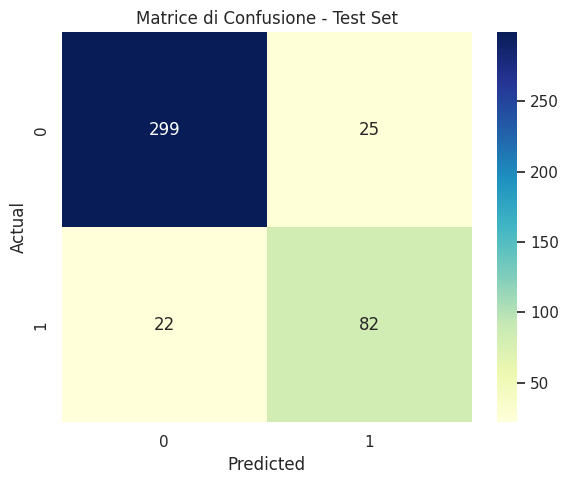

In [ ]:
# Predizioni
y_test_pred = best_rf.predict(X_test_df)

# Report
print("Classification Report - Test Set (Random Forest)")
print(classification_report(y_test, y_test_pred, digits=3))

print("Accuracy:  ", round(accuracy_score(y_test, y_test_pred), 3))
print("Precision: ", round(precision_score(y_test, y_test_pred), 3))
print("Recall:    ", round(recall_score(y_test, y_test_pred), 3))
print("F1-score:  ", round(f1_score(y_test, y_test_pred), 3))

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matrice di Confusione - Test Set")
plt.tight_layout()
plt.show()

### Interpretazione dei risultati sul Test Set

Il modello Random Forest ottimizzato mostra ottime prestazioni sul test set, con un'**accuracy complessiva del 89%**.

In particolare:
- Raggiunge un **recall del 78.8% sulla classe 1 (fallimento del trattamento)**, dimostrando una buona capacità di individuare i pazienti a rischio.
- La **precision sulla classe 1 è del 76.6%**, indicando che la maggior parte dei pazienti classificati come "a rischio" lo sono realmente.

- Il modello mantiene un **buon equilibrio tra sensibilità (recall sulla classe 1)** e **specificità (recall sulla classe 0)**, evitando sia falsi negativi critici che falsi allarmi inutili.

- La **matrice di confusione** conferma che gli errori sono contenuti, in particolare i **falsi negativi** (22 su 104), che rappresentano il tipo di errore più delicato in ambito clinico.

Nel complesso, il modello è **ben bilanciato, affidabile** e mostra ottime capacità di generalizzazione anche su dati mai visti.


# Failure Mode Analysis – Analisi degli Errori

Per comprendere meglio il comportamento del modello ottimizzato (Random Forest), ho analizzato alcuni esempi in cui le sue previsioni sono risultate errate.

- I **falsi positivi (FP)** sono i casi in cui il modello prevede un fallimento del trattamento, ma il trattamento ha avuto successo. Questo tipo di errore può generare falsi allarmi.
- I **falsi negativi (FN)** sono i casi più critici: il modello prevede un successo, ma in realtà il trattamento è fallito. Questi sono pazienti ad alto rischio non riconosciuti.

L’analisi delle prime righe di questi due gruppi mi consente di individuare eventuali pattern, situazioni borderline, valori anomali o la mancanza di feature informative che possono aver tratto in inganno il modello.



In [ ]:
# Creo un DataFrame con i dati originali e aggiungo label e predizioni del modello ottimizzato
df_val_results = X_val.copy()
df_val_results['True_Label'] = y_val
df_val_results['Predicted'] = best_rf.predict(X_val_df)
df_val_results['Correct'] = df_val_results['True_Label'] == df_val_results['Predicted']

# Esempi di False Positives (modello predice 1 ma era 0)
print("Esempi di False Positives (FP):")
display(df_val_results[(df_val_results['True_Label'] == 0) & (df_val_results['Predicted'] == 1)].head())

# Esempi di False Negatives (modello predice 0 ma era 1)
print("\nEsempi di False Negatives (FN):")
display(df_val_results[(df_val_results['True_Label'] == 1) & (df_val_results['Predicted'] == 0)].head())

Esempi di False Positives (FP):


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,symptom,treat,offtrt,cd40,cd420,cd80,cd820,True_Label,Predicted,Correct
679,232,0,26,61.8000,0,1,0,90,0,1,...,1,0,1,173,256,734,1453,0,1,False
1062,678,3,38,70.7616,0,0,1,100,0,1,...,0,1,1,317,285,716,516,0,1,False
1900,582,0,39,73.0296,0,1,0,100,0,0,...,0,0,1,254,193,606,734,0,1,False
308,624,1,28,75.7512,0,1,0,100,0,0,...,0,1,1,231,204,862,726,0,1,False
1638,876,0,36,117.0288,0,0,0,90,0,0,...,0,0,1,199,206,1228,1184,0,1,False



Esempi di False Negatives (FN):


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,symptom,treat,offtrt,cd40,cd420,cd80,cd820,True_Label,Predicted,Correct
162,981,0,41,89.90000,0,1,0,100,0,1,...,0,0,0,209,251,738,1573,1,0,False
1786,939,3,37,88.90560,0,1,0,80,0,1,...,0,1,0,260,200,2220,2050,1,0,False
930,476,3,26,57.83400,0,0,0,90,0,0,...,0,1,1,218,327,990,1155,1,0,False
587,544,1,25,63.05040,0,1,0,90,0,0,...,1,1,1,372,529,1464,1080,1,0,False
2044,413,0,28,72.03168,1,0,0,100,1,0,...,0,0,1,348,279,528,450,1,0,False


- **False Positives (FP)**: questi errori possono generare falsi allarmi e indicano che il modello tende talvolta a sovrastimare il rischio. Alcuni FP mostrano valori borderline o medi delle feature immunitarie (es. cd80, cd820), che potrebbero aver confuso il modello.

- **False Negatives (FN)**: questi sono errori più critici, poiché il modello non riconosce correttamente pazienti a rischio. Alcuni FN presentano valori molto alti nelle feature immunitarie, che il modello ha interpretato come segni positivi, anche se l’outcome reale era negativo.

Questa analisi suggerisce che il modello, pur avendo buone performance globali, può sbagliare in presenza di valori estremi o combinazioni ambigue.



# Conclusioni

In questo progetto ho sviluppato e analizzato un modello predittivo utilizzando il dataset clinico *AIDS Clinical Trials Group Study 175*, con l’obiettivo di prevedere l'esito del trattamento (variabile `cid`) a partire da informazioni demografiche, cliniche e terapeutiche dei pazienti.

Dopo una fase iniziale di esplorazione dei dati (EDA) e un’accurata preparazione del dataset, ho costruito un modello di riferimento (Logistic Regression) e successivamente un modello più complesso (Random Forest),ottimizzato tramite RandomizedSearchCV.

Il modello finale (Random Forest ottimizzata) ha raggiunto buone prestazioni sia sul validation set che sul test set, dimostrando una buona capacità di generalizzazione e di individuazione dei casi critici.

L’Ablation Study ha evidenziato quanto la feature più importante influisca sulle performance del modello: la sua rimozione ha infatti causato un netto peggioramento dei risultati.

Infine, l’analisi degli errori (Failure Mode Analysis) ha permesso di identificare profili di pazienti più difficili da classificare correttamente, in particolare i falsi negativi, che rappresentano i casi più sensibili dal punto di vista clinico.
